# Temas Tratados en el Trabajo Práctico 8

* Aprendizaje estadístico.

* Evolución de la verosimilitud de una hipótesis en función de observaciones.

* Aprendizaje no supervisado. Algoritmo K-means.

* Aprendizaje supervisado. Algoritmo Knn.

* Aprendizaje por refuerzo. Algoritmo Q-Learning.

## Ejercicios Teóricos

1. Un fabricante de tornillos vende cajas que contienen 1000 tornillos de cabeza redonda con tres tipos de recubrimiento electrolítico (cincado, cobre y níquel). Cada caja se rellena
con diferentes proporciones que pueden variar de la siguiente manera:

&emsp;&emsp;a: Todos los tornillos están recubiertos de níquel. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;b: El 70% de los tornillos están recubiertos de níquel, el 20% de cobre, el resto está cincado. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;c: El 50% de los tornillos están recubiertos de níquel, el 25% de cobre y el resto está cincado. 50 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;d: El 20 % de los tornillos están recubiertos de níquel, el 50% de cobre y el resto está cincado. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;e: Todos los tornillos están recubiertos de cobre. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;1.1 ¿Cuál es la distribución a priori sobre las hipótesis?

### Resolución

Cada hipótesis representa un tipo de caja. La **probabilidad a priori** indica qué tan probable es elegir una caja de ese tipo antes de observar los tornillos.

Las proporciones de fabricación y la composición de cada caja son:

| Hipótesis | Níquel | Cobre | Cincado | Probabilidad a priori |
|:---------:|:------:|:-----:|:------:|:---------------------:|
| $h_a$ | 100 % | 0 % | 0 % | 0.15 |
| $h_b$ | 70 % | 20 % | 10 % | 0.15 |
| $h_c$ | 50 % | 25 % | 25 % | 0.50 |
| $h_d$ | 20 % | 50 % | 30 % | 0.10 |
| $h_e$ | 0 % | 100 % | 0 % | 0.10 |

Por lo tanto, la distribución a priori es:

$$
\boxed{P(H)=\langle 0.15,\;0.15,\;0.50,\;0.10,\;0.10\rangle}
$$

Se verifica que:

$$
0.15+0.15+0.50+0.10+0.10=1
$$

Inicialmente, la hipótesis más probable es $h_c$, porque corresponde al 50 % de las cajas fabricadas.

**Supuesto utilizado:** siguiendo la presentación, consideramos las observaciones independientes e idénticamente distribuidas. Esto es exacto si se extrae con reposición y aproximado si no se devuelven los tornillos, ya que se observan solamente 10 de los 1000 tornillos de la caja.

&emsp;Considerando que los 10 primeros tornillos que se extraen de una caja de muestra son de cobre:

&emsp;&emsp;1.2 Calcule la probabilidad de cada hipótesis dado que los 10 primeros tornillos fueron de cobre.

### Resolución

Observamos que los **primeros diez tornillos extraídos son de cobre**. Queremos calcular qué tan probable es cada tipo de caja después de conocer este resultado.

Utilizamos estos símbolos:

- $h_i$: la hipótesis de que la caja pertenece al tipo $i$, donde $i$ puede ser a, b, c, d o e.
- $D_{10}$: el resultado observado, es decir, diez tornillos de cobre consecutivos.
- $P(h_i)$: probabilidad inicial de ese tipo de caja.
- $P(D_{10}\mid h_i)$: probabilidad de obtener diez tornillos de cobre si la caja es de ese tipo. Se llama **verosimilitud**.
- $P(h_i\mid D_{10})$: probabilidad actualizada de ese tipo de caja después de observar los diez tornillos. Se llama **probabilidad posterior**.

El símbolo $\mid$ se lee “dado que” o “sabiendo que”.

### 1. Probabilidad de observar diez tornillos de cobre

Como las extracciones son con reposición, la probabilidad de obtener cobre no cambia entre una extracción y otra.

Por ejemplo, en una caja del tipo b, cada extracción tiene una probabilidad de 0.20 de dar un tornillo de cobre. Para obtener diez seguidos:

$$
P(D_{10}\mid h_b)
=
\underbrace{0.20\times0.20\times\cdots\times0.20}_{10\text{ extracciones}}
=
(0.20)^{10}
$$

Hacemos lo mismo para los demás tipos de caja:

| Tipo de caja | Probabilidad de obtener cobre en una extracción | Probabilidad de obtener diez de cobre seguidos |
|:------------:|:----------------------------------------------:|:----------------------------------------------:|
| a | $0$ | $0^{10}=0$ |
| b | $0.20$ | $(0.20)^{10}=0.0000001024$ |
| c | $0.25$ | $(0.25)^{10}\approx0.000000953674$ |
| d | $0.50$ | $(0.50)^{10}=0.0009765625$ |
| e | $1$ | $1^{10}=1$ |

### 2. Actualización mediante el teorema de Bayes

El teorema de Bayes combina la probabilidad inicial de cada tipo de caja con la probabilidad de obtener los datos observados:

$$
P(h_i\mid D_{10})
=
\frac{P(D_{10}\mid h_i)\,P(h_i)}
{P(D_{10})}
$$

El denominador $P(D_{10})$ es la probabilidad total de obtener diez tornillos de cobre, considerando todos los tipos de caja:

$$
\begin{aligned}
P(D_{10})={}&
0^{10}(0.15)
+(0.20)^{10}(0.15)
+(0.25)^{10}(0.50)\\
&+(0.50)^{10}(0.10)
+1^{10}(0.10)
\end{aligned}
$$

$$
P(D_{10})\approx0.100098148447
$$

Dividir por este valor permite que las probabilidades actualizadas sumen 1.

Por ejemplo, para una caja del tipo e:

$$
P(h_e\mid D_{10})
=
\frac{1^{10}(0.10)}{0.100098148447}
\approx0.99901948
$$

### 3. Resultados

| Tipo de caja | Probabilidad después de observar diez tornillos de cobre |
|:------------:|:-------------------------------------------------------:|
| a | 0 % |
| b | 0.00001534 % |
| c | 0.00047637 % |
| d | 0.09756050 % |
| e | 99.90194779 % |

**Conclusión:** la caja es del tipo e con una probabilidad aproximada de **99.902 %**.

Al principio, el tipo c era el más probable por ser el más fabricado. Sin embargo, obtener diez tornillos de cobre consecutivos favorece fuertemente al tipo e, porque todas sus piezas son de cobre.

El tipo a queda descartado desde la primera extracción de cobre, ya que contiene únicamente tornillos de níquel.


&emsp;&emsp;1.3 Grafique la evolución de la verosimilitud de cada hipótesis en función del número de tornillos extraídos de la caja.

### Resolución

Queremos observar qué ocurre a medida que extraemos tornillos y todos resultan ser de cobre.

Llamamos:

- $n$: cantidad de tornillos extraídos.
- $D_n$: resultado de haber obtenido $n$ tornillos de cobre consecutivos.
- $h_i$: hipótesis de que la caja pertenece al tipo $i$.

El valor $n=0$ representa la situación inicial, antes de extraer tornillos.

Debemos distinguir dos cantidades:

### Verosimilitud: probabilidad de los datos para cada tipo de caja

$$
P(D_n\mid h_i)
=
\left[P(\text{cobre}\mid h_i)\right]^n
$$

Responde a la pregunta:

**“Si la caja fuera de este tipo, ¿qué probabilidad habría de obtener estos resultados?”**

Por ejemplo, para el tipo d:

$$
P(D_n\mid h_d)=(0.50)^n
$$

Antes de observar tornillos, la verosimilitud vale 1 para todas las hipótesis.

### Probabilidad posterior: probabilidad actualizada de cada tipo de caja

$$
P(h_i\mid D_n)
=
\frac{P(D_n\mid h_i)\,P(h_i)}
{\sum_j P(D_n\mid h_j)\,P(h_j)}
$$

El símbolo $\sum_j$ indica que sumamos los términos correspondientes a los cinco tipos de caja.

Esta probabilidad responde a la pregunta:

**“Después de obtener estos resultados, ¿qué tan probable es que la caja sea de este tipo?”**

El primer gráfico muestra la **verosimilitud**, como solicita el enunciado. El segundo muestra la **probabilidad posterior**, para visualizar cómo se actualizan las hipótesis mediante el aprendizaje bayesiano.

Probabilidades después de observar 10 tornillos de cobre:

h_a: 0.000000000000 (0.00000000 %)
h_b: 0.000000153449 (0.00001534 %)
h_c: 0.000004763696 (0.00047637 %)
h_d: 0.000975604959 (0.09756050 %)
h_e: 0.999019477896 (99.90194779 %)

Suma de las probabilidades: 1.000000


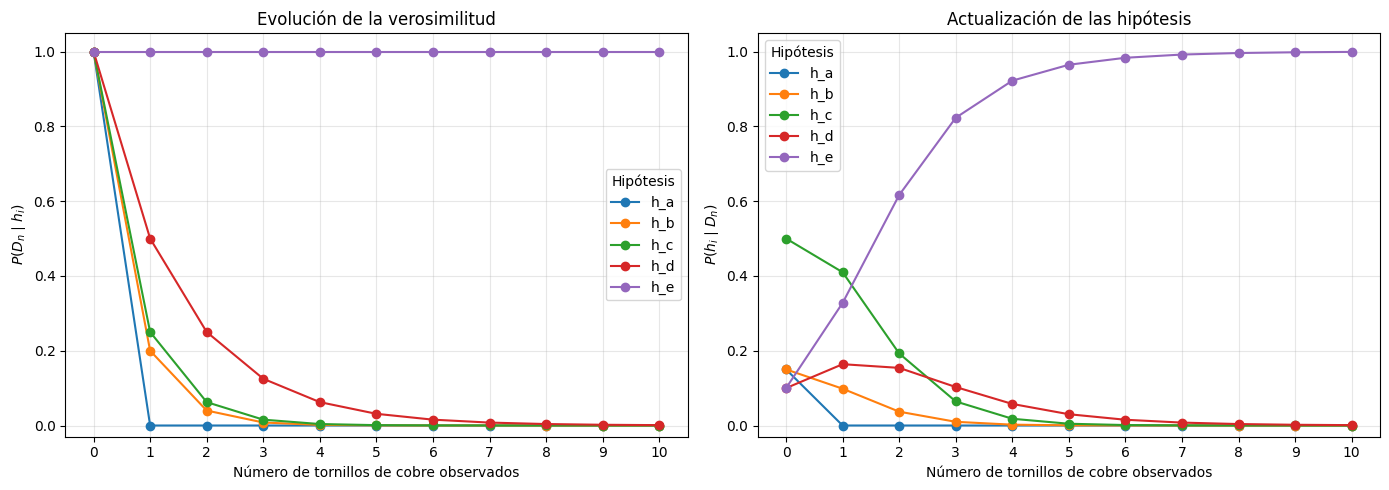

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Hipótesis, probabilidades iniciales y proporción de cobre.
hipotesis = ["h_a", "h_b", "h_c", "h_d", "h_e"]
priori = np.array([0.15, 0.15, 0.50, 0.10, 0.10])
prob_cobre = np.array([0.00, 0.20, 0.25, 0.50, 1.00])

# Incluimos n = 0 para representar la situación sin observaciones.
numero_tornillos = np.arange(11)

# Cada fila corresponde a una cantidad de observaciones.
verosimilitudes = np.ones((11, 5))

# Si todos los tornillos observados son de cobre:
# P(D_n | h_i) = P(cobre | h_i) ** n.
for n in numero_tornillos[1:]:
    verosimilitudes[n] = prob_cobre ** n

# Aplicamos Bayes: multiplicamos por la priori y normalizamos.
pesos = verosimilitudes * priori
evidencias = pesos.sum(axis=1, keepdims=True)
posteriores = pesos / evidencias

# Mostramos los resultados del inciso 1.2.
print("Probabilidades después de observar 10 tornillos de cobre:\n")

for nombre, probabilidad in zip(hipotesis, posteriores[10]):
    print(f"{nombre}: {probabilidad:.12f} ({100 * probabilidad:.8f} %)")

print(f"\nSuma de las probabilidades: {posteriores[10].sum():.6f}")

# Mostramos la verosimilitud y la probabilidad posterior por separado.
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
colores = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

for i, nombre in enumerate(hipotesis):
    ejes[0].plot(
        numero_tornillos,
        verosimilitudes[:, i],
        marker="o",
        color=colores[i],
        label=nombre,
    )

    ejes[1].plot(
        numero_tornillos,
        posteriores[:, i],
        marker="o",
        color=colores[i],
        label=nombre,
    )

ejes[0].set_title("Evolución de la verosimilitud")
ejes[0].set_ylabel(r"$P(D_n \mid h_i)$")

ejes[1].set_title("Actualización de las hipótesis")
ejes[1].set_ylabel(r"$P(h_i \mid D_n)$")

for eje in ejes:
    eje.set_xlabel("Número de tornillos de cobre observados")
    eje.set_xticks(numero_tornillos)
    eje.set_ylim(-0.03, 1.05)
    eje.grid(alpha=0.3)
    eje.legend(title="Hipótesis")

plt.tight_layout()
plt.show()

### Interpretación de los gráficos

En el gráfico de **verosimilitud**:

- $h_a$ pasa a cero desde la primera observación, porque no contiene cobre.
- Para las cajas mixtas, la probabilidad de observar únicamente cobre disminuye al aumentar la cantidad de extracciones.
- $h_e$ mantiene una verosimilitud igual a 1, porque todos sus tornillos son de cobre.

En el gráfico de **probabilidades posteriores**:

- En $n=0$ aparecen las probabilidades a priori.
- $h_e$ aumenta progresivamente hasta acercarse a 1.
- Algunas hipótesis mixtas pueden aumentar inicialmente, pero pierden probabilidad cuando se acumulan más observaciones de cobre.

Esto muestra cómo funciona el **aprendizaje bayesiano**: combinamos las probabilidades iniciales con los datos observados para actualizar la probabilidad de cada hipótesis.

&emsp;&emsp;1.4 Para cada hipótesis, ¿cuál es la probabilidad de que el cuarto tornillo extraído sea de cobre?

### Resolución

Para cada tipo de caja, queremos conocer la probabilidad de que **el cuarto tornillo extraído sea de cobre**.

Llamamos $C_4$ al evento “el cuarto tornillo es de cobre”.

Como trabajamos con reposición, la composición de la caja no cambia. Por eso, para un tipo de caja conocido, la probabilidad de obtener cobre es la misma en la primera, segunda, tercera o cuarta extracción.

| Tipo de caja | Probabilidad de que el cuarto tornillo sea de cobre |
|:------------:|:--------------------------------------------------:|
| a | 0 % |
| b | 20 % |
| c | 25 % |
| d | 50 % |
| e | 100 % |

Por ejemplo:

$$
P(C_4\mid h_b)=0.20
$$

Se lee: “La probabilidad de que el cuarto tornillo sea de cobre, sabiendo que la caja es del tipo b, es del 20 %”.

**Estas probabilidades corresponden a cada tipo de caja conocido.** Las probabilidades del inciso 1.2 responden a otra pregunta: qué tipo de caja tenemos después de observar diez tornillos de cobre.

2. ¿Qué diferencia principal existe entre un algoritmo supervisado y un algoritmo no supervisado?

### Resolución

La principal diferencia entre un **algoritmo supervisado** y un **algoritmo no supervisado** se encuentra en el tipo de datos utilizados durante el aprendizaje.

En el **aprendizaje supervisado**, los datos de entrenamiento se encuentran **etiquetados**. Esto significa que para cada entrada se conoce previamente la salida o clase correcta. El algoritmo utiliza estos ejemplos para aprender una relación entre las entradas y las salidas, de manera que posteriormente pueda predecir la respuesta correspondiente a nuevos datos.

Por ejemplo, el algoritmo **KNN (K-Nearest Neighbors)** puede utilizar puntos cuya clase ya es conocida para determinar a qué clase pertenece un nuevo punto según sus vecinos más cercanos.

En cambio, en el **aprendizaje no supervisado**, los datos no poseen etiquetas ni una respuesta conocida previamente. El algoritmo debe analizar los datos y encontrar por sí mismo patrones, estructuras o agrupaciones.

Por ejemplo, el algoritmo **K-means** divide un conjunto de puntos en grupos o *clusters* según su similitud o cercanía, sin conocer previamente a qué grupo debería pertenecer cada punto.

Por lo tanto, la diferencia principal puede resumirse de la siguiente manera:

- **Aprendizaje supervisado:** aprende a partir de ejemplos con una salida conocida o etiqueta.
- **Aprendizaje no supervisado:** trabaja con datos sin etiquetar e intenta descubrir estructuras o agrupaciones presentes en ellos.

## Ejercicios de implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

3. Genere un conjunto de 23 puntos que contengan coordenadas *xy* aleatorias con valores contenidos en el intervalo [0, 5] y grafique los puntos obtenidos en un gráfico.

&emsp;&emsp;3.1 Implemente un algoritmo K-means que clasifique 20 de los puntos en 2 grupos y grafique el resultado asignando un color a cada uno.

### Prompt

Actuá como un **profesor universitario y desarrollador experto en Inteligencia Artificial**. Necesito resolver completamente el **Ejercicio 3 del TP8, incluyendo los incisos 3.1 y 3.2**, para incorporar la resolución en mi Jupyter Notebook.

Quiero una solución **correcta, simple, didáctica y reproducible**, que me permita entender los algoritmos y explicar el trabajo en una presentación.

## Fuentes y contexto

Utilizá:

1. **TP8.ipynb:** fuente principal para el enunciado y sus requisitos.
2. **Clase 9 - Aprendizaje 2026.pdf:** referencia para la terminología y los pasos de los algoritmos.

## Enunciado

**Ejercicio 3:** Genere un conjunto de 23 puntos que contengan coordenadas xy aleatorias con valores contenidos en el intervalo [0, 5] y grafique los puntos obtenidos.

**3.1:** Implemente un algoritmo K-means que clasifique 20 de los puntos en 2 grupos y grafique el resultado asignando un color a cada uno.

**3.2:** Tome los tres puntos restantes y clasifíquelos en los grupos obtenidos anteriormente usando el algoritmo KNN. Utilice distintos valores de K y anote lo que observa con esta elección.

## Requisitos generales

- Entregá la resolución organizada en **celdas Markdown y celdas de Python**, listas para copiar y ejecutar en orden.
- Conservá los enunciados y explicá dónde agregar cada celda.
- Utilizá Python, NumPy y Matplotlib. Evitá dependencias adicionales innecesarias.
- **Implementá los pasos de K-means y KNN de manera explícita**, sin reemplazar la resolución por llamadas a clasificadores de scikit-learn.
- Programa siempre lo mas simple posible, usá funciones simples, nombres descriptivos en español y comentarios que expliquen los bloques importantes.
- Evitá clases, arquitectura compleja y código innecesario.
- Usá una semilla fija para obtener resultados reproducibles.
- En las explicaciones, utilizá palabras claras y definí los símbolos antes de usarlos. Presentá las fórmulas con LaTeX compatible con Jupyter.

## Generación y separación de los puntos

- Generá una sola vez los **23 puntos aleatorios**, con ambas coordenadas en [0, 5].
- Usá los primeros **20 puntos para K-means** y reservá los últimos **3 para KNN**.
- No regeneres los puntos entre incisos.
- Mostrá inicialmente los 23 puntos, distinguiendo los 20 usados para agrupar de los 3 reservados.
- Identificá los tres puntos reservados como P1, P2 y P3.
- No uses los puntos reservados para calcular los grupos ni los centroides.

## Inciso 3.1: K-means

Explicá brevemente:

- Qué significa aprendizaje no supervisado.
- Qué es un grupo y qué es un centroide.
- Cómo se calcula la distancia euclidiana entre dos puntos.
- Qué representa K en K-means: aquí, **K = 2 grupos**.

Implementá el algoritmo siguiendo estos pasos:

1. Elegir dos puntos distintos entre los 20 como centroides iniciales.
2. Asignar cada punto al centroide más cercano.
3. Recalcular cada centroide como el promedio de las coordenadas de los puntos asignados a su grupo.
4. Repetir hasta que las asignaciones se estabilicen o el desplazamiento de los centroides sea menor que una tolerancia.
5. Establecer un máximo de iteraciones para evitar un ciclo indefinido.

Contemplá de manera sencilla qué hacer si algún grupo queda vacío. Al finalizar, asegurate de que las etiquetas y los centroides sean coherentes entre sí.

Mostrá:

- Cantidad de iteraciones realizadas.
- Coordenadas finales de los centroides.
- Cantidad de puntos de cada grupo.
- Un gráfico con los 20 puntos coloreados según su grupo y los centroides destacados.

Explicá que K-means puede depender de la inicialización y que las etiquetas “grupo 1” y “grupo 2” son nombres arbitrarios.

## Inciso 3.2: KNN

Utilizá los **mismos 20 puntos y las etiquetas obtenidas con K-means** como ejemplos para clasificar los tres puntos reservados.

Aclaración fundamental: **KNN debe buscar vecinos entre los 20 puntos etiquetados, no solamente entre los dos centroides**. Tampoco debe volver a ejecutar K-means al incorporar los puntos nuevos.

Explicá:

- Qué significa aprendizaje supervisado.
- Cómo se usan las etiquetas generadas por K-means en este ejercicio.
- La diferencia entre **K en K-means**, que indica cantidad de grupos, y **k en KNN**, que indica cantidad de vecinos consultados.

Implementá KNN mediante:

1. Calcular la distancia del punto nuevo a cada uno de los 20 puntos.
2. Ordenar los puntos por distancia.
3. Seleccionar los k vecinos más cercanos.
4. Asignar el grupo que tenga más votos entre esos vecinos.

Probá **k = 1, 3, 5, 7 y 9**, usando votación uniforme. Estos valores impares evitan empates de votos entre los dos grupos. Si hay distancias iguales, utilizá un criterio reproducible para ordenarlas.

Para cada punto y cada valor de k, mostrá:

- Grupo asignado.
- Cantidad de vecinos de cada grupo.

Presentá una tabla comparativa y gráficos que permitan observar la clasificación de P1, P2 y P3 para cada valor de k. Conservá los mismos colores de los grupos utilizados en el inciso 3.1 y destacá los puntos nuevos con símbolos diferentes.

## Análisis de resultados

Redactá las observaciones a partir de los resultados realmente obtenidos:

- Indicá si alguno de los tres puntos cambia de grupo al modificar k.
- Si ninguno cambia, explicalo sin modificar los datos para provocar un cambio.
- Explicá que k = 1 depende del vecino más cercano y que valores mayores consideran un entorno más amplio.
- Comentá cómo puede influir la cercanía a la separación entre grupos y la cantidad de puntos de cada grupo.
- No afirmes que aumentar k siempre mejora la clasificación.
- Aclar á que no podemos medir la exactitud real de estas predicciones porque no contamos con etiquetas verdaderas externas para los tres puntos.

## Formato de entrega

Organizá la respuesta en este orden:

1. Explicación y generación de los 23 puntos.
2. Explicación e implementación de K-means.
3. Resultados y gráfico del inciso 3.1.
4. Explicación e implementación de KNN.
5. Tabla y gráficos comparativos del inciso 3.2.
6. Observaciones y conclusión breve.

No entregues únicamente código: incluí las celdas Markdown necesarias para comprender qué hacemos, por qué lo hacemos y cómo interpretar los resultados.

Si podés ejecutar el código, verificá que funcione y basá las conclusiones en esa ejecución. Si no podés ejecutarlo, indicá qué resultados deben observarse, sin inventar salidas numéricas.


### Resolución del ejercicio 3

Generamos 23 puntos aleatorios. Cada punto tiene dos coordenadas, $x$ e $y$, con valores comprendidos entre 0 y 5.

Separamos los puntos de la siguiente manera:

- **Primeros 20 puntos:** se utilizan para formar dos grupos mediante K-means.
- **Últimos 3 puntos:** se reservan para clasificarlos posteriormente mediante KNN. Los identificamos como P1, P2 y P3.

Los puntos reservados no intervienen en la formación de los grupos.

Utilizamos una **semilla fija**, que permite obtener los mismos puntos al volver a ejecutar el programa. Esto facilita reproducir y comparar los resultados.

Puntos reservados para KNN:
P1: x = 2.1858, y = 4.1634
P2: x = 3.5013, y = 1.5618
P3: x = 4.1613, y = 4.0238


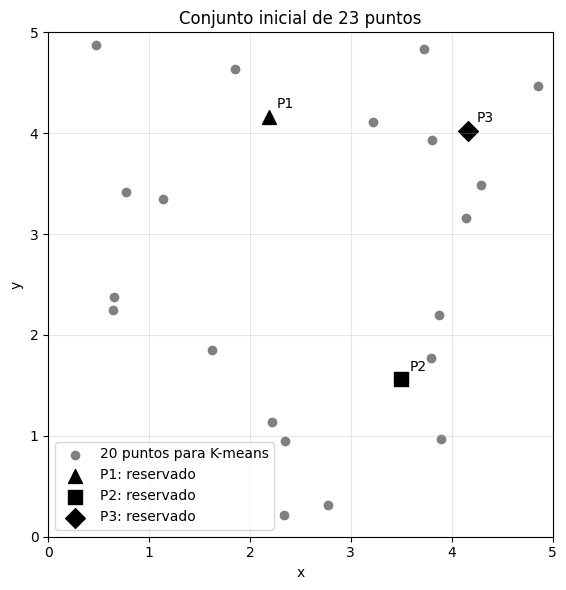

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generamos una sola vez los 23 puntos.
generador = np.random.default_rng(42)
puntos = generador.uniform(0, 5, size=(23, 2))

# Separamos los puntos sin modificar sus coordenadas.
puntos_grupos = puntos[:20]
puntos_nuevos = puntos[20:]

# Mantendremos estos colores y símbolos durante todo el ejercicio.
colores = ["tab:blue", "tab:orange"]
marcadores = ["^", "s", "D"]

print("Puntos reservados para KNN:")
for i, punto in enumerate(puntos_nuevos):
    print(f"P{i + 1}: x = {punto[0]:.4f}, y = {punto[1]:.4f}")

plt.figure(figsize=(7, 6))

plt.scatter(
    puntos_grupos[:, 0],
    puntos_grupos[:, 1],
    color="gray",
    label="20 puntos para K-means",
)

# Los puntos reservados tienen símbolos diferentes.
for i, punto in enumerate(puntos_nuevos):
    plt.scatter(
        *punto,
        color="black",
        marker=marcadores[i],
        s=100,
        label=f"P{i + 1}: reservado",
    )
    plt.annotate(
        f"P{i + 1}",
        punto,
        xytext=(6, 6),
        textcoords="offset points",
    )

plt.title("Conjunto inicial de 23 puntos")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.gca().set_aspect("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 3.1 Agrupamiento mediante K-means

K-means es un algoritmo de **aprendizaje no supervisado**: recibe puntos sin etiquetas y busca agruparlos según su cercanía.

En este ejercicio, **K = 2** indica que queremos formar dos grupos.

Cada grupo se representa mediante un **centroide**, cuyas coordenadas son el promedio de las coordenadas de sus puntos.

Para un grupo con $m$ puntos:

$$
x_{\text{centroide}}=\frac{x_1+x_2+\cdots+x_m}{m}
$$

$$
y_{\text{centroide}}=\frac{y_1+y_2+\cdots+y_m}{m}
$$

Para medir la cercanía utilizamos la **distancia euclidiana**. Entre dos puntos $A=(x_A,y_A)$ y $B=(x_B,y_B)$:

$$
d(A,B)=\sqrt{(x_A-x_B)^2+(y_A-y_B)^2}
$$

El algoritmo realiza estos pasos:

1. Selecciona dos puntos distintos como centroides iniciales.
2. Asigna cada punto al centroide más cercano.
3. Recalcula los centroides usando los puntos de cada grupo.
4. Repite hasta que los puntos ya no cambien de grupo.

Establecemos un máximo de 100 iteraciones. Si un grupo queda vacío, conservamos su centroide anterior.

En el código usamos las etiquetas internas **0 y 1**. Al mostrar los resultados las presentamos como **grupo 1 y grupo 2**.

Estos nombres son arbitrarios: no indican que un grupo sea mejor que otro. Además, K-means puede producir resultados diferentes si cambian los centroides iniciales y no garantiza encontrar el óptimo global.

Iteraciones realizadas: 4

Grupo 1: 8 puntos
Centroide: x = 2.8566, y = 1.1768

Grupo 2: 12 puntos
Centroide: x = 2.4629, y = 3.7416



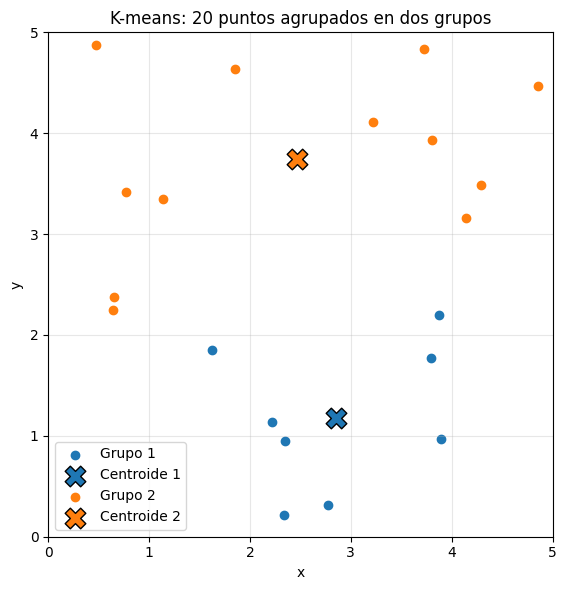

In [3]:
def k_means(datos, semilla=42, max_iteraciones=100):
    # Elegimos dos puntos distintos como centroides iniciales.
    generador_inicial = np.random.default_rng(semilla)
    indices = generador_inicial.choice(len(datos), size=2, replace=False)
    centroides = datos[indices].copy()

    for iteracion in range(1, max_iteraciones + 1):
        # Calculamos la distancia de cada punto a los dos centroides.
        # Cada fila contiene las dos distancias de un punto.
        distancias = np.linalg.norm(
            datos[:, None, :] - centroides[None, :, :],
            axis=2,
        )

        # La etiqueta es el número del centroide más cercano.
        etiquetas = np.argmin(distancias, axis=1)

        # Recalculamos los centroides como promedios.
        nuevos_centroides = centroides.copy()

        for grupo in range(2):
            miembros = datos[etiquetas == grupo]

            # Si el grupo está vacío, conservamos su centroide anterior.
            if len(miembros) > 0:
                nuevos_centroides[grupo] = miembros.mean(axis=0)

        # Comprobamos si los centroides recalculados cambian las etiquetas.
        distancias_nuevas = np.linalg.norm(
            datos[:, None, :] - nuevos_centroides[None, :, :],
            axis=2,
        )
        etiquetas_nuevas = np.argmin(distancias_nuevas, axis=1)

        centroides = nuevos_centroides

        # Si no hay cambios, las etiquetas y los centroides son coherentes.
        if np.array_equal(etiquetas, etiquetas_nuevas):
            return etiquetas, centroides, iteracion

    raise RuntimeError(
        "K-means no se estabilizó: aumentar max_iteraciones."
    )


# Solo usamos los 20 puntos destinados al agrupamiento.
etiquetas, centroides, iteraciones = k_means(puntos_grupos)

print(f"Iteraciones realizadas: {iteraciones}\n")

for grupo in range(2):
    cantidad = np.sum(etiquetas == grupo)
    print(f"Grupo {grupo + 1}: {cantidad} puntos")
    print(
        f"Centroide: x = {centroides[grupo, 0]:.4f}, "
        f"y = {centroides[grupo, 1]:.4f}\n"
    )

plt.figure(figsize=(7, 6))

for grupo in range(2):
    miembros = puntos_grupos[etiquetas == grupo]

    plt.scatter(
        miembros[:, 0],
        miembros[:, 1],
        color=colores[grupo],
        label=f"Grupo {grupo + 1}",
    )

    plt.scatter(
        *centroides[grupo],
        color=colores[grupo],
        marker="X",
        s=220,
        edgecolor="black",
        label=f"Centroide {grupo + 1}",
    )

plt.title("K-means: 20 puntos agrupados en dos grupos")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.gca().set_aspect("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Resultados de K-means

Con las semillas utilizadas, el algoritmo se estabiliza después de **4 iteraciones**.

| Grupo | Cantidad de puntos | Coordenadas del centroide |
|:-----:|:------------------:|:-------------------------:|
| 1 | 8 | $(2.8566,\;1.1768)$ |
| 2 | 12 | $(2.4629,\;3.7416)$ |

En el gráfico:

- Los puntos azules pertenecen al grupo 1.
- Los puntos naranjas pertenecen al grupo 2.
- Las marcas con forma de X representan los centroides.

El grupo 1 reúne principalmente los puntos de la zona inferior y el grupo 2 los de la zona superior.

Los grupos no necesitan tener la misma cantidad de puntos: K-means asigna cada punto al centroide más cercano, sin imponer tamaños iguales.

Los tres puntos reservados todavía no fueron clasificados.


&emsp;&emsp;3.2 Tome los tres puntos restantes y clasifíquelos en los grupos obtenidos anteriormente usando el algoritmo Knn. Utilice distintos valores de K y anote lo que observa con esta elección.

### 3.2 Clasificación mediante KNN

En el inciso anterior, K-means organizó 20 puntos en dos grupos. Por lo tanto, ahora conocemos las coordenadas y el grupo asignado a cada uno de esos puntos.

El objetivo de este inciso es **asignar un grupo a los tres puntos reservados: P1, P2 y P3**, utilizando los 20 puntos ya etiquetados como referencia.

Para hacerlo aplicamos **KNN**, cuyo nombre significa “K vecinos más cercanos”.

### ¿Cómo clasifica KNN un punto nuevo?

La idea es observar a qué grupos pertenecen sus vecinos más cercanos y elegir el grupo que tenga más representantes.

Para cada punto nuevo:

1. Calculamos su distancia a cada uno de los 20 puntos conocidos.
2. Ordenamos esos puntos desde el más cercano hasta el más lejano.
3. Seleccionamos los primeros **k vecinos**.
4. Contamos cuántos vecinos pertenecen a cada grupo.
5. Asignamos el punto nuevo al grupo con más votos.

Cada vecino aporta **un voto**, independientemente de su distancia, siempre que esté entre los k seleccionados.

Por ejemplo, si usamos **k = 5** y encontramos:

| Grupo | Cantidad de vecinos seleccionados |
|:-----:|:---------------------------------:|
| 1 | 3 |
| 2 | 2 |

El punto nuevo se asigna al **grupo 1**, porque obtiene la mayoría de los votos.

### ¿Cómo medimos la cercanía?

Utilizamos la distancia euclidiana entre el punto nuevo y cada punto conocido:

$$
d=\sqrt{(x_{\text{nuevo}}-x_{\text{conocido}})^2
+(y_{\text{nuevo}}-y_{\text{conocido}})^2}
$$

Una distancia menor indica que los puntos están más cerca.

### ¿Por qué es aprendizaje supervisado?

KNN necesita ejemplos que ya tengan una clasificación. En nuestro ejercicio, estos ejemplos son los 20 puntos con las etiquetas obtenidas mediante K-means.

KNN utiliza esas etiquetas para clasificar los nuevos puntos. No vuelve a formar los grupos ni modifica los centroides.

**Importante:** los vecinos se buscan entre los 20 puntos conocidos, no entre los dos centroides. Además, los tres puntos nuevos se clasifican por separado: ninguno se incorpora como vecino para clasificar a los otros.

### Diferencia entre K-means y KNN

| Algoritmo | Qué hace | Qué significa K |
|-----------|----------|-----------------|
| K-means | Forma grupos a partir de puntos sin etiquetas. | Cantidad de grupos. |
| KNN | Clasifica puntos nuevos utilizando puntos etiquetados. | Cantidad de vecinos consultados. |

En K-means usamos **2 grupos**. En KNN probamos **k = 1, 3, 5, 7 y 9 vecinos**.

Usamos valores impares porque, al existir solamente dos grupos, permiten evitar empates en la votación.

### ¿Qué muestra el código?

Primero presenta una tabla donde cada fila corresponde a un punto nuevo y un valor de k:

- **Votos grupo 1:** cantidad de vecinos seleccionados que pertenecen al grupo 1.
- **Votos grupo 2:** cantidad de vecinos seleccionados que pertenecen al grupo 2.
- **Grupo asignado:** grupo que obtiene más votos.

La suma de los votos de ambos grupos debe ser igual a k.

Después muestra un gráfico para cada valor de k:

- Los círculos representan los 20 puntos conocidos.
- El triángulo representa P1.
- El cuadrado representa P2.
- El rombo representa P3.
- El color de cada punto nuevo indica el grupo asignado por KNN.

Las posiciones de todos los puntos se mantienen iguales. Lo que podría cambiar al modificar k es el color asignado a los puntos nuevos.


P1
k     Votos grupo 1     Votos grupo 2     Grupo asignado
1     0                 1                 2
3     0                 3                 2
5     0                 5                 2
7     0                 7                 2
9     0                 9                 2
11    1                 10                2
13    2                 11                2
15    3                 12                2
17    5                 12                2
19    7                 12                2

P2
k     Votos grupo 1     Votos grupo 2     Grupo asignado
1     1                 0                 1
3     3                 0                 1
5     5                 0                 1
7     6                 1                 1
9     8                 1                 1
11    8                 3                 1
13    8                 5                 1
15    8                 7                 1
17    8                 9                 2
19    8                 11                

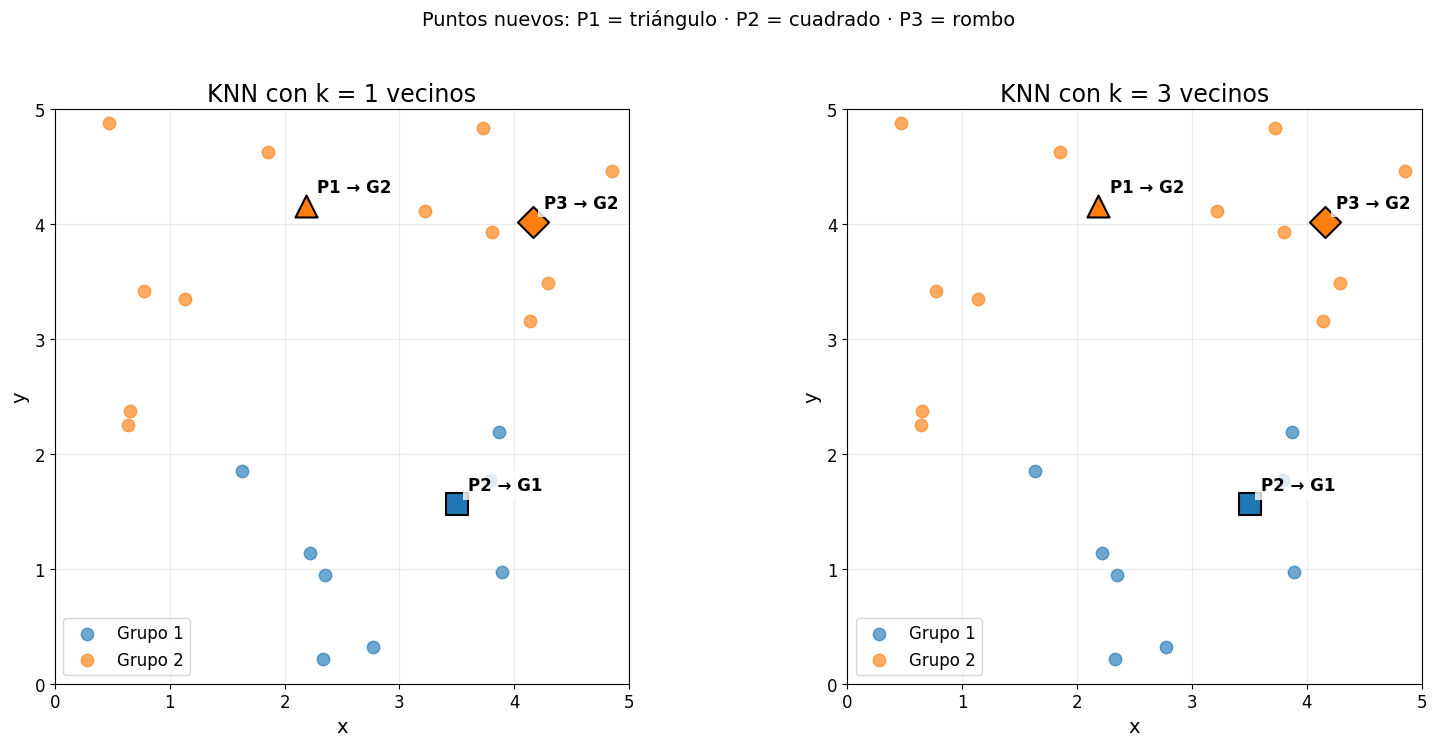

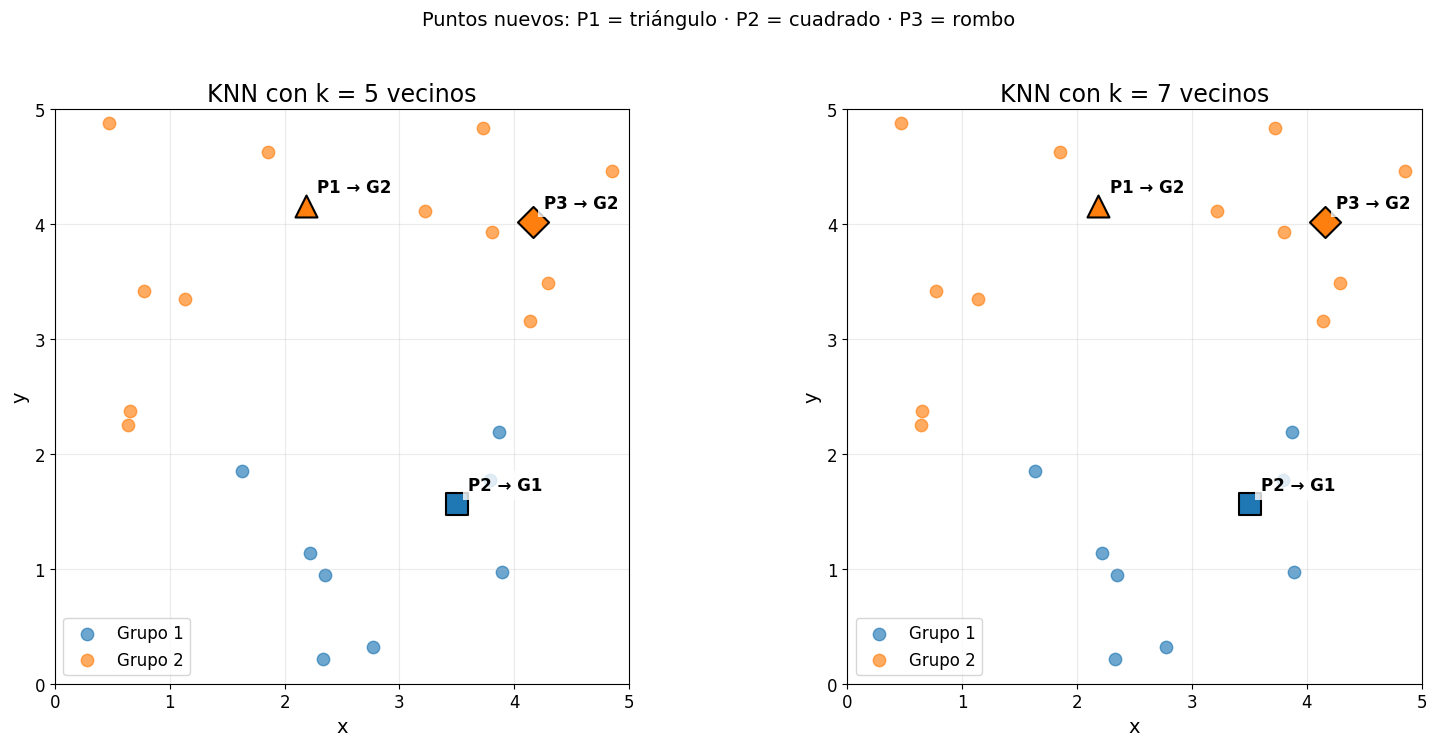

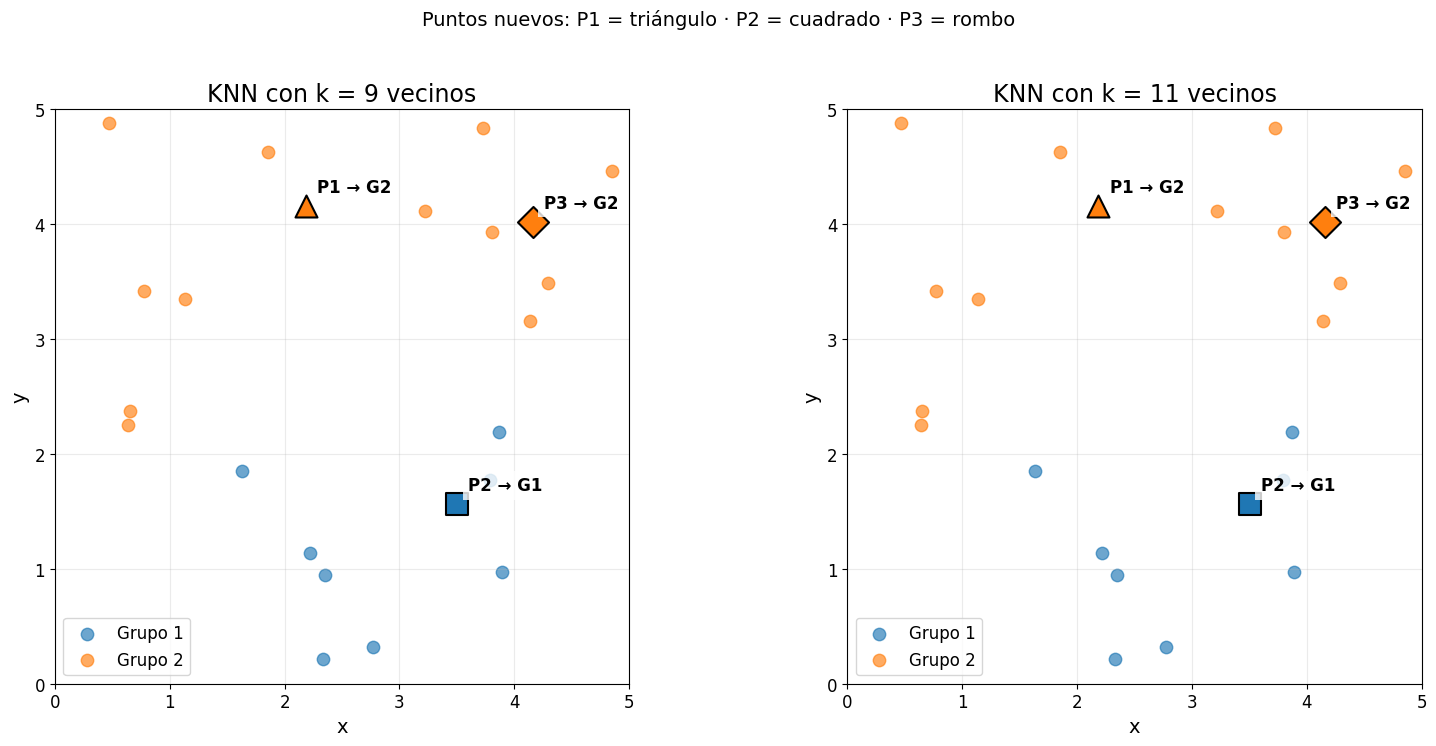

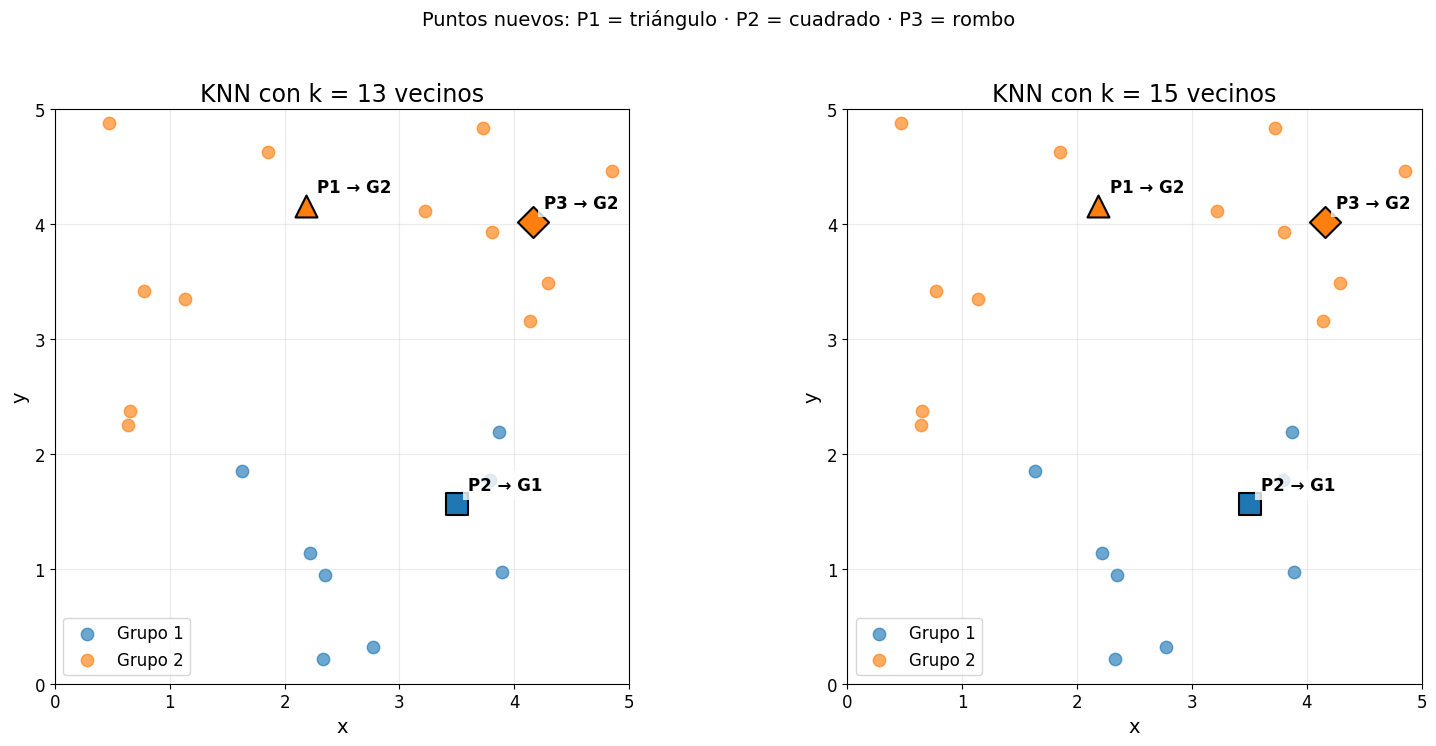

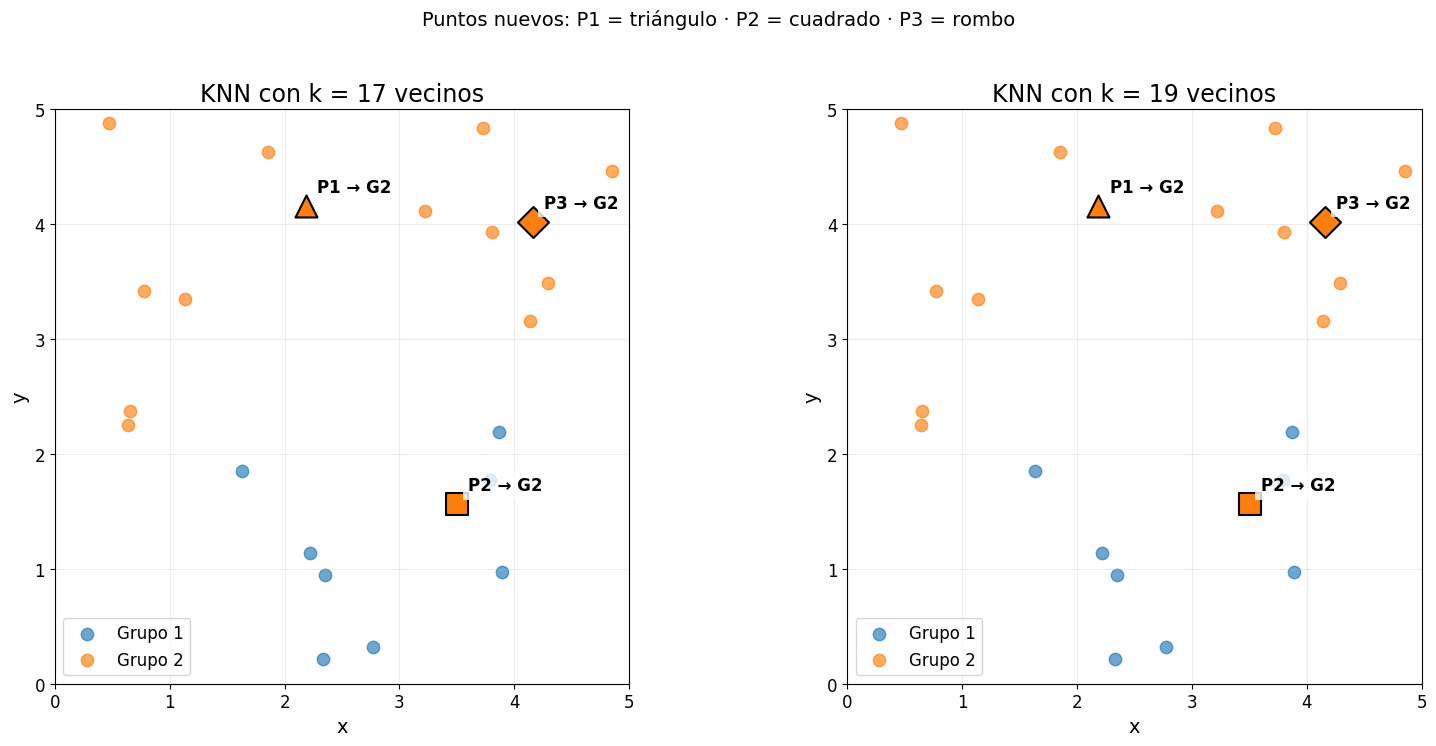

In [5]:
def clasificar_knn(punto, datos, etiquetas, k):
    # Calculamos la distancia a los 20 puntos conocidos.
    distancias = np.linalg.norm(datos - punto, axis=1)

    # Seleccionamos los k vecinos más cercanos.
    # Si hay distancias iguales, conservamos el orden original.
    vecinos = np.argsort(distancias, kind="stable")[:k]

    # Cada vecino aporta un voto al grupo al que pertenece.
    votos = np.bincount(etiquetas[vecinos], minlength=2)

    # Asignamos el grupo que obtiene más votos.
    grupo = np.argmax(votos)

    return grupo, votos


# Todos los valores impares desde 1 hasta 19.
valores_k = list(range(1, 20, 2))

# Guardamos los grupos asignados y los votos.
resultados = np.zeros((len(valores_k), 3), dtype=int)
votos_resultados = np.zeros((len(valores_k), 3, 2), dtype=int)

for fila, k in enumerate(valores_k):
    for i, punto in enumerate(puntos_nuevos):
        grupo, votos = clasificar_knn(
            punto, puntos_grupos, etiquetas, k
        )

        resultados[fila, i] = grupo
        votos_resultados[fila, i] = votos

# Mostramos una tabla por punto para facilitar la comparación.
for i in range(3):
    print(f"\nP{i + 1}")
    print(
        f"{'k':<6}{'Votos grupo 1':<18}"
        f"{'Votos grupo 2':<18}{'Grupo asignado'}"
    )

    for fila, k in enumerate(valores_k):
        votos = votos_resultados[fila, i]
        grupo = resultados[fila, i]

        print(
            f"{k:<6}{votos[0]:<18}"
            f"{votos[1]:<18}{grupo + 1}"
        )

# Mostramos dos gráficos grandes por figura.
# Se generan cinco figuras en total.
for inicio in range(0, len(valores_k), 2):
    fig, ejes = plt.subplots(1, 2, figsize=(16, 7.5))

    for columna, eje in enumerate(ejes):
        fila = inicio + columna
        k = valores_k[fila]

        # Los puntos conocidos mantienen sus grupos de K-means.
        for grupo in range(2):
            miembros = puntos_grupos[etiquetas == grupo]

            eje.scatter(
                miembros[:, 0],
                miembros[:, 1],
                color=colores[grupo],
                s=80,
                alpha=0.65,
                label=f"Grupo {grupo + 1}",
            )

        # Destacamos los tres puntos nuevos.
        for i, punto in enumerate(puntos_nuevos):
            grupo = resultados[fila, i]

            eje.scatter(
                *punto,
                color=colores[grupo],
                marker=marcadores[i],
                s=250,
                edgecolor="black",
                linewidth=1.5,
                zorder=3,
            )

            # G1 y G2 significan grupo 1 y grupo 2.
            eje.annotate(
                f"P{i + 1} → G{grupo + 1}",
                punto,
                xytext=(8, 10),
                textcoords="offset points",
                fontsize=12,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.8,
                ),
                zorder=4,
            )

        eje.set_title(f"KNN con k = {k} vecinos", fontsize=17)
        eje.set_xlabel("x", fontsize=14)
        eje.set_ylabel("y", fontsize=14)
        eje.set_xlim(0, 5)
        eje.set_ylim(0, 5)
        eje.set_aspect("equal")
        eje.tick_params(labelsize=12)
        eje.grid(alpha=0.25)
        eje.legend(loc="lower left", fontsize=12)

    fig.suptitle(
        "Puntos nuevos: P1 = triángulo · P2 = cuadrado · P3 = rombo",
        fontsize=14,
    )

    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

### Resultados y comparación de los valores de k

Probamos todos los valores impares desde 1 hasta 19. La clasificación obtenida es:

| Cantidad de vecinos k | Grupo de P1 | Grupo de P2 | Grupo de P3 |
|:---------------------:|:-----------:|:-----------:|:-----------:|
| 1 | 2 | 1 | 2 |
| 3 | 2 | 1 | 2 |
| 5 | 2 | 1 | 2 |
| 7 | 2 | 1 | 2 |
| 9 | 2 | 1 | 2 |
| 11 | 2 | 1 | 2 |
| 13 | 2 | 1 | 2 |
| 15 | 2 | 1 | 2 |
| 17 | 2 | 2 | 2 |
| 19 | 2 | 2 | 2 |

P1 y P3 permanecen en el grupo 2 para todos los valores probados.

**P2 permanece en el grupo 1 hasta k = 15, pero cambia al grupo 2 con k = 17 y k = 19.**

En los gráficos, este cambio se observa porque el cuadrado que representa P2 pasa de azul a naranja. La posición del punto permanece igual: cambia solamente su clasificación.

Las anotaciones **G1 y G2** significan grupo 1 y grupo 2.

### ¿Por qué cambia P2 cuando usamos muchos vecinos?

P2 se encuentra en la zona inferior, cerca de puntos del grupo 1. Sin embargo, al aumentar k comenzamos a incluir puntos más lejanos del grupo 2.

Los votos obtenidos para P2 son:

| k | Votos del grupo 1 | Votos del grupo 2 | Grupo asignado |
|:---:|:----------------:|:----------------:|:--------------:|
| 1 | 1 | 0 | 1 |
| 3 | 3 | 0 | 1 |
| 5 | 5 | 0 | 1 |
| 7 | 6 | 1 | 1 |
| 9 | 8 | 1 | 1 |
| 11 | 8 | 3 | 1 |
| 13 | 8 | 5 | 1 |
| 15 | 8 | 7 | 1 |
| 17 | 8 | 9 | 2 |
| 19 | 8 | 11 | 2 |

Con **k = 9**, ya participan los ocho puntos del grupo 1 y solamente uno del grupo 2.

A partir de allí, aumentar k incorpora exclusivamente puntos del grupo 2, porque ya se incluyeron todos los del grupo 1.

Con **k = 17**, el grupo 2 obtiene nueve votos frente a ocho del grupo 1 y cambia la clasificación de P2.

Este resultado muestra que una cantidad muy grande de vecinos puede hacer que pese más el tamaño total de los grupos que la cercanía de los puntos.

### ¿Por qué elegimos k = 9?

Consideramos **k = 9 una elección razonable para este ejemplo**, porque consulta varios vecinos y mantiene una mayoría clara para los tres puntos:

| Punto | Votos del grupo 1 | Votos del grupo 2 | Grupo asignado |
|:-----:|:----------------:|:----------------:|:--------------:|
| P1 | 0 | 9 | 2 |
| P2 | 8 | 1 | 1 |
| P3 | 2 | 7 | 2 |

Así, la decisión no depende solamente de un vecino, como ocurre con k = 1, y todavía conserva información sobre el entorno cercano de cada punto.

Además, evita el cambio de P2 observado al consultar casi todos los puntos con k = 17 o k = 19.

**Esto no demuestra que k = 9 sea el valor óptimo ni el único adecuado.** Los valores 11, 13 y 15 también mantienen las mismas clasificaciones.

Para determinar qué valor obtiene mayor exactitud necesitaríamos ejemplos con etiquetas de referencia y comparar las predicciones mediante una validación. Como aquí no contamos con esas etiquetas, justificamos k = 9 como una elección práctica basada en los resultados observados.

### Conclusión

La cantidad de vecinos influye en la clasificación de KNN:

- Con pocos vecinos, la decisión es muy local y puede ser sensible a un punto aislado.
- Con muchos vecinos, se incluyen puntos más lejanos y puede dominar el grupo más numeroso.

En este conjunto, P2 cambia de grupo a partir de k = 17, mientras que P1 y P3 mantienen su clasificación.

Elegimos k = 9 porque combina una consulta de varios vecinos con mayorías claras para los tres puntos, sin atribuirle un óptimo que no fue demostrado.

4. La imagen mostrada abajo muestra una red de salas y cómo se comunican entre ellas. Implemente un algoritmo Q-Learning con un factor despreciativo $γ = 0.9$. La matriz de recompensas debe asignar un valor de 0 a cada camino accesible y un valor de 100 a caminos que lleven a la sala del tesoro.

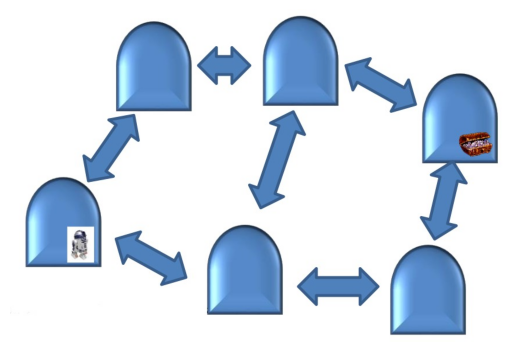

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1dkDruEIPa7f-BAmjI47TZl3bxaqYf6a9"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

&emsp;&emsp;4.1 Dibuje un diagrama con la asignación de recompensas correspondiente a cada estado.

&emsp;&emsp;4.2 Diseñe y muestre la matriz de recompensas.

&emsp;&emsp;4.3 Obtenga la matriz Q óptima, normalícela respecto al valor máximo encontrado y grafique la política obtenida en el diagrama mostrado inicialmente.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2017) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)